# SR2 · Pairs Trading and Cointegration

*Signal Research track*

Two similar companies should not drift apart forever. Pairs trading bets that when they do, the gap will close. This notebook builds the classic version step by step, then follows it out-of-sample to see how it holds up.

## 1. Motivation

Coca-Cola and PepsiCo sell similar products to the same customers and face the same costs. If Coca-Cola's stock jumps 10% while PepsiCo's stays flat, with no news to explain it, many traders would bet that the gap will close: sell Coca-Cola, buy PepsiCo. That bet doesn't depend on whether the market goes up or down, only on the *relationship* between the two stocks. It is called **statistical arbitrage**, and for decades it was one of the most profitable quantitative strategies. Is it still?

## 2. Intuition

Picture a person walking a dog on a leash. Both wander unpredictably, and you can't forecast where either will be in an hour. But the *distance* between them can't grow without limit: the leash pulls them back together. If the dog is unusually far ahead, a good bet is that the gap will shrink.

Two stock prices that are tied by such a leash are called **cointegrated**. Each price wanders like a random walk, but some combination of them (the **spread**) keeps returning to an average level. Pairs trading:

1. Find two stocks with a leash.
2. Measure how stretched the leash is right now.
3. When it is unusually stretched, buy the one that is behind and sell the one that is ahead. Close the trade when the gap returns to normal.

Note that **correlation is not the leash.** Two stocks can move together day by day (high correlation of returns) and still drift apart over years. Cointegration is about the *levels* of prices, not their daily moves.

## 3. The math

**The spread.** Using log prices $p^A_t, p^B_t$, find the **hedge ratio** $\beta$ by regressing one on the other:
$$
p^A_t = c + \beta\,p^B_t + s_t .
$$
The residual $s_t$ is the spread. Holding 1 unit of A against $\beta$ units of B means you hold the spread.

**Cointegration test (Engle–Granger).** If $s_t$ is **stationary** (it keeps returning to a fixed mean, with a stable variance), the pair is cointegrated. The test asks whether $s_t$ has a unit root, i.e. whether it behaves like a random walk. A small p-value (e.g. below 0.05) is evidence that it does *not*, and therefore that the leash exists.

**How fast does it snap back?** Model the spread's daily change as
$$
\Delta s_t = a + b\,s_{t-1} + \varepsilon_t, \qquad b < 0 .
$$
Each day the spread closes a fraction $-b$ of its distance from the mean. The **half-life**, the time for a gap to halve, is
$$
h = -\frac{\ln 2}{\ln(1 + b)} \approx -\frac{\ln 2}{b} \text{ days}.
$$

**Trading rule.** Standardise the spread with its mean $\mu_s$ and standard deviation $\sigma_s$: $z_t = (s_t - \mu_s)/\sigma_s$. Then:
- **Enter** when $|z_t| > 2$: short the spread if $z_t > 2$ (A is expensive relative to B), long the spread if $z_t < -2$.
- **Exit** when $z_t$ crosses back through 0.

## 4. Code it

### 4.1 Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint

prices = pd.read_csv("../data/prices.csv", index_col="date", parse_dates=True)
meta = pd.read_csv("../data/meta.csv")

COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
plt.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 100, "axes.prop_cycle": plt.cycler(color=COLORS),
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": 0.3, "lines.linewidth": 1.5, "font.size": 11,
})

logp = np.log(prices.drop(columns=["^VIX", "^IRX"]))   # log prices (the two indices are not prices)
returns = prices.pct_change()
A, B = "KO", "PEP"
formation = slice("2012", "2016")   # we choose and fit the pair on this period only

### 4.2 Fit the pair on the formation period

In [2]:
f = logp.loc[formation, [A, B]]
fit = sm.OLS(f[A], sm.add_constant(f[B])).fit()       # p_A = c + beta p_B + s
beta = fit.params[B]
spread = logp[A] - beta * logp[B]                       # spread for the whole sample, with the formation beta

p_value = coint(f[A], f[B])[1]                           # Engle-Granger test
print(f"Hedge ratio beta = {beta:.2f}")
print(f"Engle-Granger p-value (2012-2016): {p_value:.3f}")
print(f"Correlation of daily returns: {returns.loc[formation, A].corr(returns.loc[formation, B]):.2f}")

# Half-life: regress the daily change of the spread on yesterday's level
s_f = spread[formation]
ar = sm.OLS(s_f.diff().dropna(), sm.add_constant(s_f.shift(1).dropna())).fit()
b = ar.params.iloc[1]
print(f"b = {b:.4f}  ->  half-life = {-np.log(2) / np.log(1 + b):.0f} trading days")

Hedge ratio beta = 0.51
Engle-Granger p-value (2012-2016): 0.005
Correlation of daily returns: 0.65
b = -0.0266  ->  half-life = 26 trading days


On 2012–2016, KO/PEP looks like a textbook pair:

- The Engle–Granger p-value is 0.005: strong evidence that the spread was stationary.
- Daily returns are only moderately correlated (0.65). Cointegration and correlation measure different things.
- The spread closes half of any gap in about 26 trading days, roughly five weeks. That is fast enough to trade.

(We picked this pair *and* this period knowing it works in-sample. Notebook 6 warns what that means.)

### 4.3 Trading the spread

In [3]:
mu_s, sd_s = s_f.mean(), s_f.std()          # frozen at the end of the formation period
z = ((spread - mu_s) / sd_s)["2012":]       # z_t with formation parameters, from the start of formation

def pair_positions(z, entry=2.0, exit=0.0):
    """+1 = long spread (buy A, sell beta x B), -1 = short spread, 0 = flat."""
    pos, out = 0, []
    for v in z.values:
        if pos == 0:
            if v > entry:
                pos = -1                     # A rich vs B: short the spread
            elif v < -entry:
                pos = 1                      # A cheap vs B: long the spread
        elif (pos == 1 and v >= -exit) or (pos == -1 and v <= exit):
            pos = 0                          # spread back to normal: close
        out.append(pos)
    return pd.Series(out, index=z.index)

position = pair_positions(z).shift(1)                                   # trade on the next day
spread_ret = (returns[A] - beta * returns[B]) / (1 + beta)              # return per $1 of gross exposure
pnl = (position * spread_ret).dropna()

def sharpe(r):
    return np.sqrt(252) * r.mean() / r.std()

print(f"In-sample (2012-2016):      Sharpe {sharpe(pnl['2012':'2016']):.2f}")
print(f"Out-of-sample (2017-2026):  Sharpe {sharpe(pnl['2017':]):.2f}")
print("\nP&L by year (sum of daily returns):")
print(pnl.groupby(pnl.index.year).sum().map("{:+.1%}".format).to_string())

In-sample (2012-2016):      Sharpe 1.34
Out-of-sample (2017-2026):  Sharpe -0.15

P&L by year (sum of daily returns):
date
2012     +8.8%
2013     +4.7%
2014     +0.0%
2015     +4.9%
2016     +4.6%
2017     +7.4%
2018     -1.8%
2019     -4.8%
2020    +29.0%
2021     -1.2%
2022     -5.1%
2023     +1.7%
2024     -8.4%
2025    -10.4%
2026    -18.6%


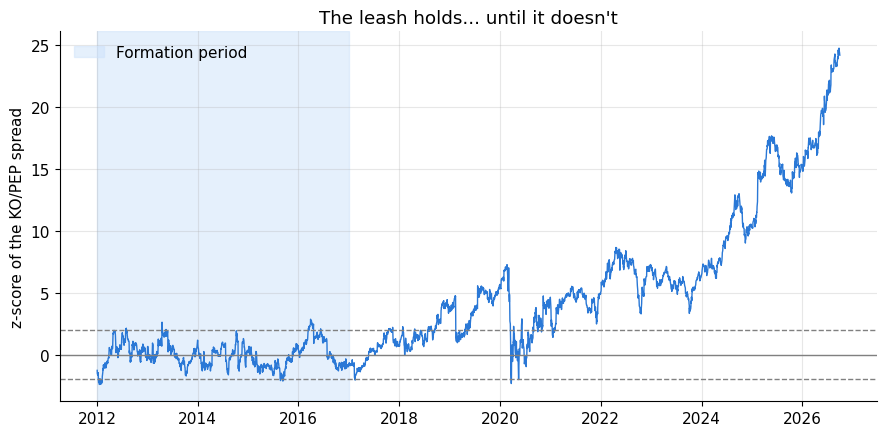

In [4]:
fig, ax = plt.subplots()
ax.plot(z.index, z, color=COLORS[0], linewidth=1)
for lvl in [-2, 2]:
    ax.axhline(lvl, color="grey", ls="--", linewidth=1)
ax.axhline(0, color="grey", linewidth=1)
ax.axvspan(pd.Timestamp("2012-01-01"), pd.Timestamp("2016-12-31"), color="#cde2fb", alpha=0.5, label="Formation period")
ax.set_ylabel("z-score of the KO/PEP spread")
ax.set_title("The leash holds... until it doesn't")
ax.legend(frameon=False, loc="upper left")
plt.tight_layout()
plt.show()

In-sample, the strategy earns a Sharpe ratio of about 1.3, with a gain every year. Out-of-sample, it keeps working in 2017. Then the leash snaps. From 2018 on, the z-score drifts upwards and never comes back: by 2026 it is above 20, meaning Coca-Cola outperformed PepsiCo by more than 20 formation-period standard deviations. The strategy entered a short-spread trade, waiting for a reversion that never came, and kept losing. The large 2020 gain came from one lucky swing during the COVID crash. Without it, the out-of-sample result would be much worse.

The cause is fundamental, not statistical. The two companies' businesses diverged (PepsiCo has a large snack-food business, Coca-Cola does not), and so did investors' view of them.

### 4.4 Risk controls: a stop and a time limit

Professional pairs traders limit the damage when a relationship breaks. Two common rules: close the trade if $|z|$ exceeds a stop level (here 4), and close it if it has been open much longer than the half-life suggests (here 3 × 26 ≈ 80 days). After a stop, wait for the spread to come back inside the entry band before trading again.

In [5]:
def pair_positions_controlled(z, entry=2.0, exit=0.0, stop=4.0, max_days=80):
    pos, days, locked, out = 0, 0, False, []
    for v in z.values:
        if locked and abs(v) < entry:
            locked = False                                   # spread is back in range: allowed again
        if pos == 0 and not locked:
            if v > entry and v < stop:
                pos, days = -1, 0
            elif v < -entry and v > -stop:
                pos, days = 1, 0
        elif pos != 0:
            days += 1
            if (pos == 1 and v >= -exit) or (pos == -1 and v <= exit):
                pos = 0                                      # normal exit
            elif abs(v) >= stop or days > max_days:
                pos, locked = 0, True                        # stop-out or time-out
        out.append(pos)
    return pd.Series(out, index=z.index)

pnl_ctrl = (pair_positions_controlled(z).shift(1) * spread_ret).dropna()
print(f"With controls, out-of-sample Sharpe: {sharpe(pnl_ctrl['2017':]):.2f}")
print(f"Out-of-sample total P&L: without {pnl['2017':].sum():+.1%}, with controls {pnl_ctrl['2017':].sum():+.1%}")

With controls, out-of-sample Sharpe: 0.36
Out-of-sample total P&L: without -12.2%, with controls +13.8%


Stops and time limits turn a −12% out-of-sample result into +14%. They do this by cutting losing trades early and refusing to re-enter while the spread stays far from its old mean. The Sharpe ratio of 0.36 is modest, and these particular stop settings were chosen after seeing the chart, so treat the improvement as a demonstration, not a result. The lesson stands, though: **in pairs trading, the risk controls matter as much as the entry signal.**

### 4.5 A systematic test: every same-sector pair, re-estimated each year

One pair is an anecdote. Here we test the idea at scale: all 71 same-sector pairs in our data. To give the method its best chance, the hedge ratio is re-estimated daily over the past year and the z-score uses a rolling 60-day mean and standard deviation, so the leash is allowed to move.

Pairs tested: 71
Portfolio of all pairs: Sharpe -0.12, return -0.3% per year
Share of pairs with positive average P&L: 48%


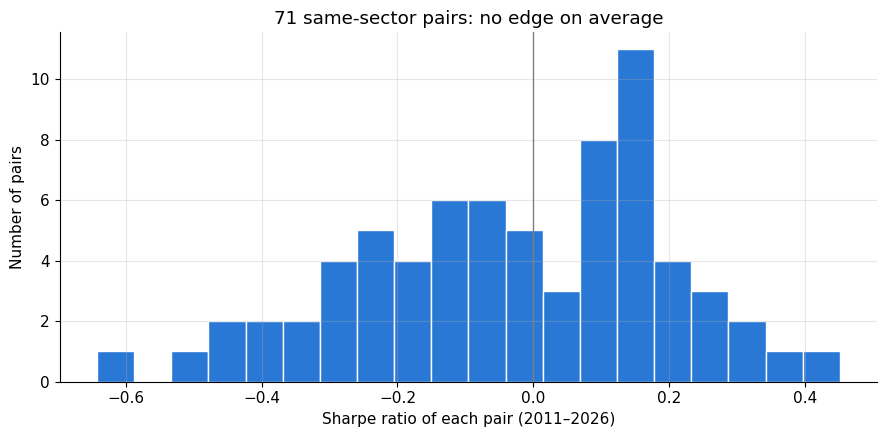

In [6]:
from itertools import combinations
stocks = meta[meta.asset_type == "stock"]

def rolling_pair_pnl(a, b, beta_window=252, z_window=60):
    bt = logp[a].rolling(beta_window).cov(logp[b]) / logp[b].rolling(beta_window).var()   # rolling beta
    s = logp[a] - bt * logp[b]
    zz = (s - s.rolling(z_window).mean()) / s.rolling(z_window).std()
    pos = pair_positions(zz.fillna(0)).shift(1)
    b_lag = bt.shift(1)
    return pos * (returns[a] - b_lag * returns[b]) / (1 + b_lag.abs())

all_pairs = {f"{a}/{b}": rolling_pair_pnl(a, b)
             for _, g in stocks.groupby("sector") for a, b in combinations(g.ticker, 2)}
P = pd.DataFrame(all_pairs)["2011":]
portfolio = P.mean(axis=1)                   # equal weight across all pairs

print(f"Pairs tested: {P.shape[1]}")
print(f"Portfolio of all pairs: Sharpe {sharpe(portfolio):.2f}, return {portfolio.mean() * 252:+.1%} per year")
print(f"Share of pairs with positive average P&L: {(P.mean() > 0).mean():.0%}")

fig, ax = plt.subplots()
ax.hist(P.apply(sharpe), bins=20, color=COLORS[0], edgecolor="white")
ax.axvline(0, color="grey", linewidth=1)
ax.set_xlabel("Sharpe ratio of each pair (2011–2026)")
ax.set_ylabel("Number of pairs")
ax.set_title("71 same-sector pairs: no edge on average")
plt.tight_layout()
plt.show()

Across all 71 same-sector pairs, with parameters updated over time, the average result is roughly zero: a Sharpe ratio of about −0.1, and as many pairs lose as win. The histogram is centred on zero, which is what you would see if the strategy had no edge at all. This matches published research: classic pairs trading on large, liquid US stocks has stopped working as more traders run it.

This is an important result for the Signal Research team. **Most ideas fail when tested properly**, and recognising a null result is a skill. The successful versions of this idea are more refined. SR3 shows one refinement: a hedge ratio that adapts smoothly over time.

## 5. Takeaways and where it breaks

- **Cointegration, not correlation.** A pair needs a long-run link between price levels. High daily correlation is not enough.
- **Relationships break.** Companies change: new products, acquisitions, different exposure to interest rates. A leash estimated on five years of data can snap. Always plan for that with stops and time limits.
- **In-sample pairs look great.** Choosing the best-looking pair out of many is the multiple-testing problem from notebook 6 again.
- **Simple pairs trading on large US stocks is crowded.** Its profits have shrunk a lot since the 1990s. What still works in practice is usually more sophisticated: many pairs or baskets at once, faster data, factor-neutral spreads, and very low costs.
- **Costs are ignored here.** Each trade opens and closes two positions, plus borrow costs for the short side.

**What you could build:** a pair-monitoring tool: track the spread, z-score, half-life and a rolling cointegration p-value for a watch-list of pairs, and flag when a relationship looks like it is breaking. Notebook SR3 adds an adaptive hedge ratio.